# Лабораторная работа 4: Самописный MLP на CPU
# Бинарная классификация
# Датасет: Breast Cancer Wisconsin (Diagnostic)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import time

# 1. Загрузка и подготовка данных

In [2]:
print("=" * 60)
print("ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ")
print("=" * 60)

# Загрузка датасета
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Размер данных: {X.shape}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Распределение классов: {np.bincount(y)}")
print(f"Признаки: {data.feature_names.tolist()}")

# Разделение на train/val/test (60/20/20) со стратификацией
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nРазмеры выборок:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Val:   {X_val.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")

# Стандартизация признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
Размер данных: (569, 30)
Количество классов: 2
Распределение классов: [212 357]
Признаки: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Размеры выборок:
  Train: 341 samples
  Val:   114 samples
  Test:  114 samples


# 2. Реализация MLP

In [3]:
class MLP:
    """
    Многослойный перцептрон для бинарной классификации.
    
    Архитектура:
    - Входной слой: n_features нейронов
    - Скрытые слои: ReLU активация
    - Выходной слой: 1 нейрон, сигмоида
    """
    
    def __init__(self, layer_sizes, learning_rate=0.001, 
                 l2_lambda=0.001, random_state=42):
        """
        Инициализация MLP.
        
        Args:
            layer_sizes: список размеров слоев [вход, скрытый1, скрытый2, ..., выход]
            learning_rate: скорость обучения
            l2_lambda: коэффициент L2-регуляризации
            random_state: seed для воспроизводимости
        """
        np.random.seed(random_state)
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes)
        
        # Инициализация весов и смещений (Xavier/Glorot)
        self.weights = []
        self.biases = []
        
        for i in range(self.num_layers - 1):
            # Xavier инициализация для ReLU
            limit = np.sqrt(6.0 / (layer_sizes[i] + layer_sizes[i+1]))
            w = np.random.uniform(-limit, limit, (layer_sizes[i], layer_sizes[i+1]))
            b = np.zeros((1, layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def _sigmoid(self, x):
        """Сигмоидная функция активации."""
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))
    
    def _sigmoid_derivative(self, x):
        """Производная сигмоиды."""
        sig = self._sigmoid(x)
        return sig * (1 - sig)
    
    def _relu(self, x):
        """ReLU функция активации."""
        return np.maximum(0, x)
    
    def _relu_derivative(self, x):
        """Производная ReLU."""
        return (x > 0).astype(float)
    
    def _forward(self, X, training=True):
        """
        Прямой проход.
        
        Returns:
            activations: список активаций всех слоев
            z_values: список значений до активации
        """
        activations = [X]
        z_values = []
        
        for i in range(self.num_layers - 1):
            z = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            z_values.append(z)
            
            if i == self.num_layers - 2:  # Выходной слой
                a = self._sigmoid(z)
            else:  # Скрытые слои
                a = self._relu(z)
            
            activations.append(a)
        
        return activations, z_values
    
    def _compute_loss(self, y_true, y_pred, activations):
        """
        Вычисление бинарной кросс-энтропии с L2-регуляризацией.
        """
        # Бинарная кросс-энтропия
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        
        # L2-регуляризация
        l2_reg = 0
        for w in self.weights:
            l2_reg += np.sum(w ** 2)
        loss += (self.l2_lambda / 2) * l2_reg
        
        return loss
    
    def _backward(self, X, y, activations, z_values):
        """
        Обратный проход (backpropagation).
        """
        m = X.shape[0]
        
        # Градиенты для весов и смещений
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)
        
        # Выходной слой
        y_pred = activations[-1]
        delta = y_pred - y.reshape(-1, 1)  # (m, 1)
        
        # Для выходного слоя
        grads_w[-1] = np.dot(activations[-2].T, delta) / m + self.l2_lambda * self.weights[-1]
        grads_b[-1] = np.sum(delta, axis=0, keepdims=True) / m
        
        # Для скрытых слоев
        for i in range(self.num_layers - 2, 0, -1):
            delta = np.dot(delta, self.weights[i].T) * self._relu_derivative(z_values[i-1])
            grads_w[i-1] = np.dot(activations[i-1].T, delta) / m + self.l2_lambda * self.weights[i-1]
            grads_b[i-1] = np.sum(delta, axis=0, keepdims=True) / m
        
        return grads_w, grads_b
    
    def train_step(self, X_batch, y_batch):
        """
        Один шаг обучения на батче.
        """
        # Прямой проход
        activations, z_values = self._forward(X_batch)
        y_pred = activations[-1]
        
        # Вычисление градиентов
        grads_w, grads_b = self._backward(X_batch, y_batch, activations, z_values)
        
        # Обновление параметров
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * grads_w[i]
            self.biases[i] -= self.learning_rate * grads_b[i]
        
        return self._compute_loss(y_batch, y_pred, activations)
    
    def fit(self, X, y, X_val=None, y_val=None, epochs=100, batch_size=32,
            verbose=True, early_stopping_patience=10):
        """
        Обучение модели.
        """
        n_samples = X.shape[0]
        history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}
        
        best_val_loss = float('inf')
        patience_counter = 0
        best_weights = None
        best_biases = None
        
        for epoch in range(epochs):
            # Перемешивание данных
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            epoch_loss = 0
            num_batches = 0
            
            # Обучение по батчам
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                batch_loss = self.train_step(X_batch, y_batch)
                epoch_loss += batch_loss
                num_batches += 1
            
            epoch_loss /= num_batches
            history['loss'].append(epoch_loss)
            
            # Оценка на обучающей выборке
            train_pred, _ = self._forward(X, training=False)
            train_acc = self.accuracy(y, (train_pred[-1] >= 0.5).astype(int).flatten())
            history['accuracy'].append(train_acc)
            
            # Оценка на валидационной выборке
            if X_val is not None and y_val is not None:
                val_pred, _ = self._forward(X_val, training=False)
                val_acc = self.accuracy(y_val, (val_pred[-1] >= 0.5).astype(int).flatten())
                val_loss = self._compute_loss(y_val, val_pred[-1], None)
                history['val_loss'].append(val_loss)
                history['val_accuracy'].append(val_acc)
                
                # Early stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    # Сохраняем лучшие веса
                    best_weights = [w.copy() for w in self.weights]
                    best_biases = [b.copy() for b in self.biases]
                else:
                    patience_counter += 1
                    if patience_counter >= early_stopping_patience:
                        if verbose:
                            print(f"\n✅ Early stopping at epoch {epoch+1}")
                        # Восстанавливаем лучшие веса
                        if best_weights is not None:
                            self.weights = best_weights
                            self.biases = best_biases
                        break
                
                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs} - "
                          f"loss: {epoch_loss:.4f}, "
                          f"val_loss: {val_loss:.4f}, "
                          f"acc: {train_acc:.4f}, "
                          f"val_acc: {val_acc:.4f}")
        
        return history
    
    def predict_proba(self, X):
        """Предсказание вероятностей."""
        activations, _ = self._forward(X, training=False)
        return activations[-1].flatten()
    
    def predict(self, X, threshold=0.5):
        """Предсказание классов."""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def accuracy(self, y_true, y_pred):
        """Вычисление точности."""
        return np.mean(y_true == y_pred)

# 3. Создание и обучение модели

In [4]:
print("\n" + "=" * 60)
print("СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ")
print("=" * 60)

# Архитектура: 30 -> 64 -> 32 -> 1
model = MLP(
    layer_sizes=[30, 64, 32, 1],
    learning_rate=0.001,
    l2_lambda=0.001,
    random_state=42
)

print(f"Архитектура: {model.layer_sizes}")
print(f"Количество параметров: {sum(w.size + b.size for w, b in zip(model.weights, model.biases))}")

# Обучение
start_time = time.time()

history = model.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=200,
    batch_size=32,
    verbose=True,
    early_stopping_patience=20
)

training_time = time.time() - start_time
print(f"\n✅ Обучение завершено за {training_time:.2f} секунд")


СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛИ
Архитектура: [30, 64, 32, 1]
Количество параметров: 4097
Epoch 10/200 - loss: 0.7537, val_loss: 0.7586, acc: 0.6334, val_acc: 0.6053
Epoch 20/200 - loss: 0.7468, val_loss: 0.7553, acc: 0.7859, val_acc: 0.7719
Epoch 30/200 - loss: 0.7510, val_loss: 0.7574, acc: 0.8622, val_acc: 0.8860
Epoch 40/200 - loss: 0.7598, val_loss: 0.7639, acc: 0.9062, val_acc: 0.9123

✅ Early stopping at epoch 41

✅ Обучение завершено за 0.17 секунд


# 4. Визуализация обучения

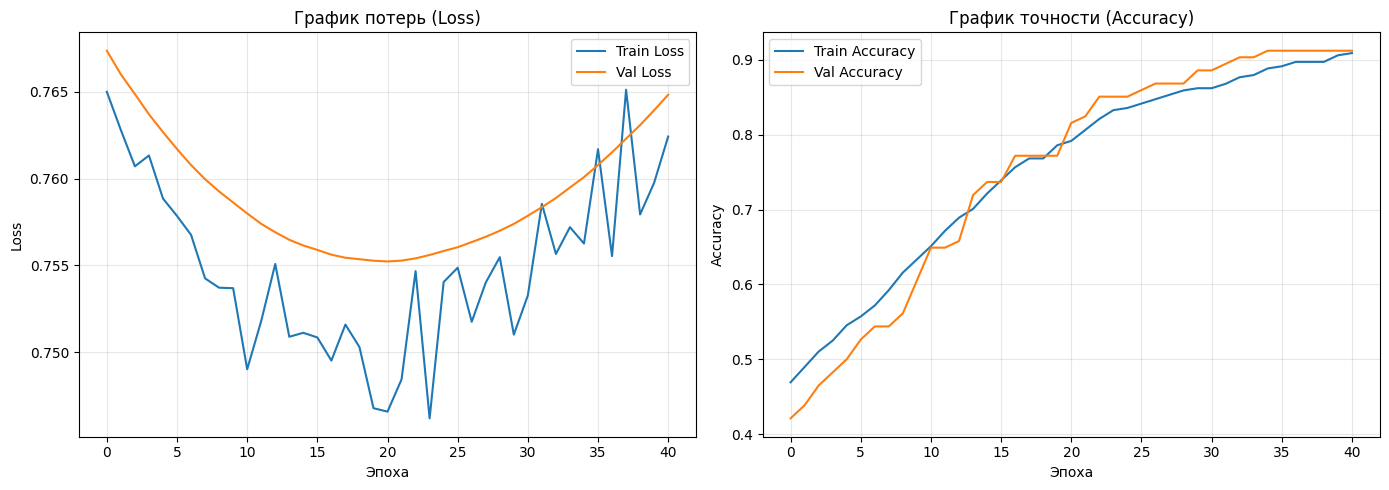

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
axes[0].plot(history['loss'], label='Train Loss')
if 'val_loss' in history and history['val_loss']:
    axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('График потерь (Loss)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График точности
axes[1].plot(history['accuracy'], label='Train Accuracy')
if 'val_accuracy' in history and history['val_accuracy']:
    axes[1].plot(history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('График точности (Accuracy)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 5. Оценка на тестовой выборке

In [6]:
print("\n" + "=" * 60)
print("ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)

# Предсказания
y_pred_proba = model.predict_proba(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Метрики
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")


ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
Accuracy:  0.7982 (79.82%)
Precision: 0.9016 (90.16%)
Recall:    0.7639 (76.39%)
F1-score:  0.8271 (82.71%)
ROC-AUC:   0.8674 (86.74%)


# 6. Матрица ошибок и классификационный отчет

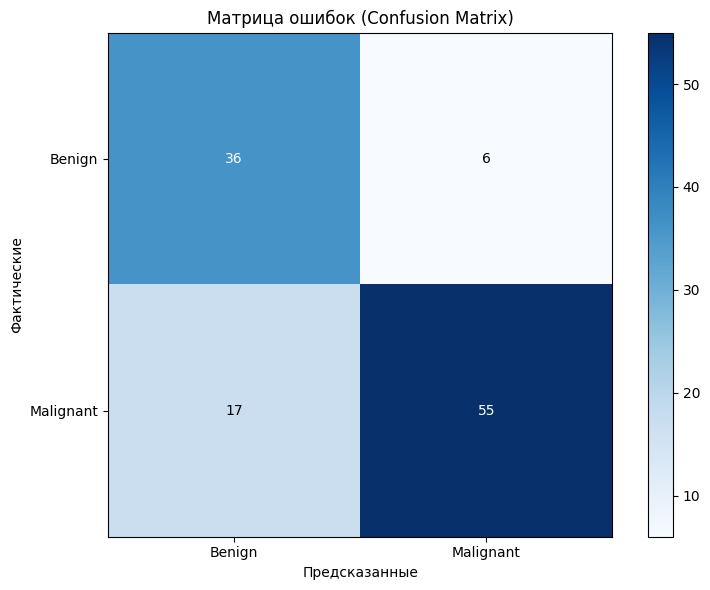


Классификационный отчет:
              precision    recall  f1-score   support

      Benign       0.68      0.86      0.76        42
   Malignant       0.90      0.76      0.83        72

    accuracy                           0.80       114
   macro avg       0.79      0.81      0.79       114
weighted avg       0.82      0.80      0.80       114



In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанные')
plt.ylabel('Фактические')
plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.yticks([0, 1], ['Benign', 'Malignant'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

print("\nКлассификационный отчет:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


# 7. Поиск оптимального порога

In [8]:
print("\n" + "=" * 60)
print("ПОИСК ОПТИМАЛЬНОГО ПОРОГА (τ)")
print("=" * 60)

# Поиск порога, максимизирующего F1 на валидации
val_pred_proba = model.predict_proba(X_val)

thresholds = np.linspace(0.1, 0.9, 100)
best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    pred_val = (val_pred_proba >= thresh).astype(int)
    f1_val = f1_score(y_val, pred_val)
    if f1_val > best_f1:
        best_f1 = f1_val
        best_threshold = thresh

print(f"Оптимальный порог (по F1): {best_threshold:.3f}")

# Метрики с оптимальным порогом
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print(f"\nМетрики с порогом τ = {best_threshold:.3f}:")
print(f"Accuracy:  {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)")
print(f"Precision: {precision_opt:.4f} ({precision_opt*100:.2f}%)")
print(f"Recall:    {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"F1-score:  {f1_opt:.4f} ({f1_opt*100:.2f}%)")

# Сравнение с порогом 0.5
print(f"\nСравнение порогов:")
print(f"  τ = 0.500: F1 = {f1:.4f}")
print(f"  τ = {best_threshold:.3f}: F1 = {f1_opt:.4f} (лучший)")


ПОИСК ОПТИМАЛЬНОГО ПОРОГА (τ)
Оптимальный порог (по F1): 0.456

Метрики с порогом τ = 0.456:
Accuracy:  0.8333 (83.33%)
Precision: 0.8272 (82.72%)
Recall:    0.9306 (93.06%)
F1-score:  0.8758 (87.58%)

Сравнение порогов:
  τ = 0.500: F1 = 0.8271
  τ = 0.456: F1 = 0.8758 (лучший)


# 8. ROC-кривая

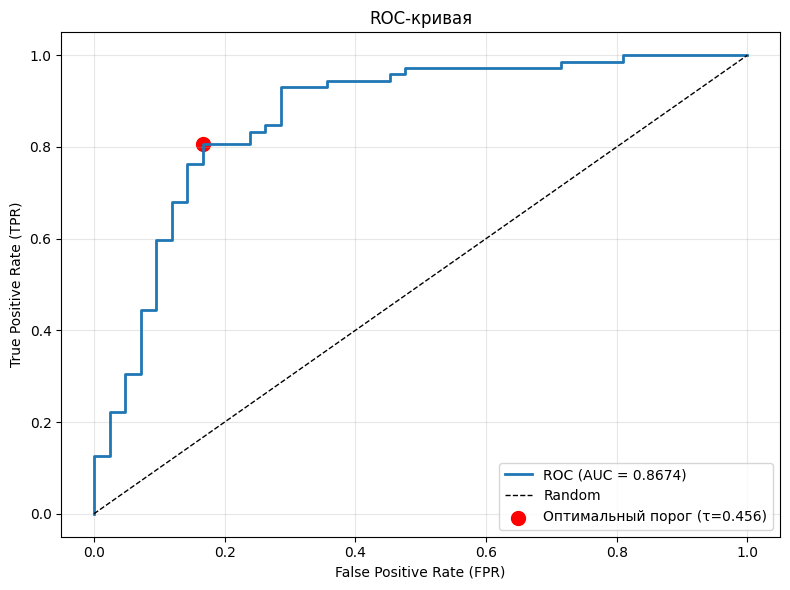

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True, alpha=0.3)

# Отметка оптимального порога
idx = np.argmin(np.abs(fpr - (1 - tpr)))  # Ближайший к (0,1)
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, 
           label=f'Оптимальный порог (τ={best_threshold:.3f})')
plt.legend()

plt.tight_layout()
plt.show()

# 9. Выводы

In [10]:
print("\n" + "=" * 60)
print("ВЫВОДЫ")
print("=" * 60)

print(f"""
1. Датасет: Breast Cancer Wisconsin (Diagnostic)
   - Образцов: {X.shape[0]}
   - Признаков: {X.shape[1]}
   - Классов: 2 (Benign/Malignant)

2. Архитектура MLP: {model.layer_sizes}
   - Параметров: {sum(w.size + b.size for w, b in zip(model.weights, model.biases))}

3. Результаты на тестовой выборке:
   - Accuracy:  {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)
   - Precision: {precision_opt:.4f} ({precision_opt*100:.2f}%)
   - Recall:    {recall_opt:.4f} ({recall_opt*100:.2f}%)
   - F1-score:  {f1_opt:.4f} ({f1_opt*100:.2f}%)
   - ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)

4. Оптимальный порог: τ = {best_threshold:.3f}
   - Выбран по максимизации F1 на валидационной выборке
   - Критерий Юдена: J = TPR - FPR = {tpr[idx] - fpr[idx]:.4f}

5. Время обучения: {training_time:.2f} секунд
""")

print("=" * 60)


ВЫВОДЫ

1. Датасет: Breast Cancer Wisconsin (Diagnostic)
   - Образцов: 569
   - Признаков: 30
   - Классов: 2 (Benign/Malignant)

2. Архитектура MLP: [30, 64, 32, 1]
   - Параметров: 4097

3. Результаты на тестовой выборке:
   - Accuracy:  0.8333 (83.33%)
   - Precision: 0.8272 (82.72%)
   - Recall:    0.9306 (93.06%)
   - F1-score:  0.8758 (87.58%)
   - ROC-AUC:   0.8674 (86.74%)

4. Оптимальный порог: τ = 0.456
   - Выбран по максимизации F1 на валидационной выборке
   - Критерий Юдена: J = TPR - FPR = 0.6389

5. Время обучения: 0.17 секунд

